# Advanced Trajectory Prediction (Social Pooling & Transformers)
This notebook implements an advanced multi-modal Trajectory Prediction model designed for hackathons. It uses Social Pooling to account for nearby agents and difference-based coordinates for stable training.


## env setup


In [1]:
!pip install nuscenes-devkit torch torchvision numpy matplotlib


## drive mount


In [16]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
except ImportError:
    print('error')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## config


In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import math
import matplotlib.pyplot as plt

from nuscenes.nuscenes import NuScenes
from nuscenes.prediction import PredictHelper

# Data Config
DATAROOT = '/content/drive/MyDrive/nuscenes'
VERSION = 'v1.0-mini'

print("Loading nuScenes (this may take a minute)...")
nusc = NuScenes(version=VERSION, dataroot=DATAROOT, verbose=True)
helper = PredictHelper(nusc)


Loading nuScenes (this may take a minute)...
Loading NuScenes tables for version v1.0-mini...
23 category,
8 attribute,
4 visibility,
911 instance,
12 sensor,
120 calibrated_sensor,
31206 ego_pose,
8 log,
10 scene,
404 sample,
31206 sample_data,
18538 sample_annotation,
4 map,
Done loading in 7.249 seconds.
Reverse indexing ...
Done reverse indexing in 0.1 seconds.


## data extraction




In [17]:

PAST_SEC, FUT_SEC, HZ = 2, 3, 2
P_FRAMES, F_FRAMES = int(PAST_SEC * HZ), int(FUT_SEC * HZ)
valid_cats = ['human.pedestrian.adult', 'vehicle.bicycle']
MAX_NEIGHBORS = 5

def get_data(max_samples=2000):
    t_past, t_fut, n_past = [], [], []
    count = 0

    print('loading trajectories...')
    for inst in nusc.instance:
        cat = nusc.get('category', inst['category_token'])['name']
        if cat not in valid_cats:
            continue

        ann_tok = inst['first_annotation_token']
        # loop through annotations
        while ann_tok:
            ann = nusc.get('sample_annotation', ann_tok)
            samp_tok = ann['sample_token']

            try:
                # get absolute coords first
                p_glob = helper.get_past_for_agent(inst['token'], samp_tok, seconds=PAST_SEC, in_agent_frame=False, just_xy=True)
                f_glob = helper.get_future_for_agent(inst['token'], samp_tok, seconds=FUT_SEC, in_agent_frame=False, just_xy=True)

                if len(p_glob) == P_FRAMES and len(f_glob) == F_FRAMES:
                    p_glob = np.array(p_glob[::-1])
                    f_glob = np.array(f_glob)

                    # anchor to current pos (0,0)
                    curr_pos = p_glob[-1]
                    p_loc = p_glob - curr_pos
                    f_loc = f_glob - curr_pos

                    # --- social context stuff ---
                    # get neighbors in the same frame
                    neighbors = []
                    all_anns = nusc.get('sample', samp_tok)['anns']
                    for n_tok in all_anns:
                        n_ann = nusc.get('sample_annotation', n_tok)
                        if n_ann['instance_token'] == inst['token']:
                            continue # skip self

                        n_p_glob = helper.get_past_for_agent(n_ann['instance_token'], samp_tok, seconds=PAST_SEC, in_agent_frame=False, just_xy=True)
                        if len(n_p_glob) == P_FRAMES:
                            n_p_glob = np.array(n_p_glob[::-1])
                            n_p_loc = n_p_glob - curr_pos
                            neighbors.append(n_p_loc)

                    # filter to closest x neighbors
                    if len(neighbors) > 0:
                        # sort by distance to us
                        neighbors.sort(key=lambda x: np.linalg.norm(x[-1]))

                    # pad if we don't have enough
                    neighbors = neighbors[:MAX_NEIGHBORS]
                    while len(neighbors) < MAX_NEIGHBORS:
                        neighbors.append(np.zeros((P_FRAMES, 2)))

                    t_past.append(p_loc)
                    t_fut.append(f_loc)
                    n_past.append(np.array(neighbors))

                    count += 1
                    # print("found valid!", count)
                    break # just take one slice per object so we dont overfit
            except Exception as e:
                # print(e)
                pass

            if count >= max_samples: break
            ann_tok = ann['next']

        if count >= max_samples: break

    return np.array(t_past), np.array(t_fut), np.array(n_past)

X_target, Y_future, X_neigh = get_data(max_samples=2000)
# check shapes
print(f"shapes -> X: {X_target.shape}, Y: {Y_future.shape}, N: {X_neigh.shape}")


loading trajectories...
shapes -> X: (188, 4, 2), Y: (188, 6, 2), N: (188, 5, 4, 2)


## offset processing


In [18]:
def get_offsets(traj):
    # calculate step-by-step velocities (delta x, delta y)
    # offset[0] stays absolute, the rest are diffs
    offsets = np.zeros_like(traj)
    offsets[:, 0] = traj[:, 0]
    offsets[:, 1:] = traj[:, 1:] - traj[:, :-1]
    return offsets

X_target_off = get_offsets(X_target)
Y_future_off = get_offsets(Y_future) # predict future step-by-step
# print("X offsets shape:", X_target_off.shape)

class TrajDataset(Dataset):
    def __init__(self, t_off, neigh, y_off):
        # convert everything to tensors right away
        self.t_off = torch.tensor(t_off, dtype=torch.float32)
        self.neigh = torch.tensor(neigh, dtype=torch.float32)
        self.y_off = torch.tensor(y_off, dtype=torch.float32)

    def __len__(self):
        return len(self.t_off)

    def __getitem__(self, idx):
        return self.t_off[idx], self.neigh[idx], self.y_off[idx]

dataset = TrajDataset(X_target_off, X_neigh, Y_future_off)

# TODO: try increasing batch size if it trains too slow
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)
# dataloader = DataLoader(dataset, batch_size=32, shuffle=True, num_workers=2) # colab crashes with workers sometimes


## transformer (social)

In [19]:

# class BaselineLSTM(nn.Module):
#     pass # abandoned this, transformers are better for this

class TrajNet(nn.Module):
    def __init__(self, in_dim=2, d_model=128, nhead=4, layers=4, out_dim=2, fut_steps=6, modes=3):
        super(TrajNet, self).__init__()
        self.d_model = d_model
        self.fut_steps = fut_steps
        self.modes = modes

        # input embeddings
        self.tgt_emb = nn.Linear(in_dim, d_model)
        self.nbr_emb = nn.Linear(in_dim, d_model)

        # fuse target and social context
        self.fusion = nn.Linear(d_model * 2, d_model)

        # main backbone
        enc_layer = nn.TransformerEncoderLayer(d_model, nhead, dim_feedforward=256, batch_first=True)
        self.transformer = nn.TransformerEncoder(enc_layer, layers)

        # output heads
        self.prob_head = nn.Linear(d_model, modes)
        self.traj_head = nn.Linear(d_model, modes * fut_steps * out_dim)

    def forward(self, tgt_past, nbr_past):
        # tgt_past: (B, S, 2)
        # nbr_past: (B, N, S, 2)
        B, N, S, _ = nbr_past.shape

        t_feat = self.tgt_emb(tgt_past)
        # print("t_feat:", t_feat.shape)

        # --- social pooling ---
        # flatten batch and neighbors so we can pass through linear layer
        n_flat = nbr_past.view(B*N, S, 2)
        n_feat = self.nbr_emb(n_flat)
        n_feat = n_feat.view(B, N, S, self.d_model)

        # max pool over the neighbors dimension (dim=1)
        soc_ctx, _ = torch.max(n_feat, dim=1)

        # concat and fuse
        fused = self.fusion(torch.cat([t_feat, soc_ctx], dim=-1))

        # push through transformer
        encoded = self.transformer(fused)

        # grab the last timestep to predict the future
        last_h = encoded[:, -1, :]

        # get probabilities and reshape trajectories
        probs = torch.softmax(self.prob_head(last_h), dim=-1)
        trajs = self.traj_head(last_h)
        trajs = trajs.view(-1, self.modes, self.fut_steps, 2) # (B, M, S, 2)

        return probs, trajs

# model = TrajNet(d_model=256, layers=6) # too slow on colab gpu maybe?
model = TrajNet()


## loss and offset integration

In [20]:
def calc_loss(pred_probs, pred_offsets, target_offsets):
    # preds: (B, M, S, 2)
    B, M, S, _ = pred_offsets.shape

    # gotta do cumsum since the network outputs velocities
    # add a dimension so broadcasting works against the M modes
    target_abs = torch.cumsum(target_offsets, dim=1).unsqueeze(1)
    pred_abs = torch.cumsum(pred_offsets, dim=2)

    # assert pred_abs.shape == (B, M, S, 2) # check shapes

    # MSE across the steps
    dist = torch.norm(pred_abs - target_abs, dim=-1) # (B, M, S)
    ade_modes = dist.mean(dim=-1) # (B, M)

    # minN ADE: find the mode that got closest to reality
    best_idx = torch.argmin(ade_modes, dim=-1)
    best_ade = ade_modes[torch.arange(B), best_idx]

    # classification loss so probabilities get better at picking the right path
    # ce_loss = nn.CrossEntropyLoss()(pred_probs, best_idx)
    ce_fn = nn.CrossEntropyLoss()
    ce_loss = ce_fn(pred_probs, best_idx)

    total = best_ade.mean() + ce_loss

    # track FDE (just the last step's distance)
    fde_modes = dist[:, :, -1]
    best_fde = fde_modes[torch.arange(B), best_idx]

    return total, best_ade.mean(), best_fde.mean()


## training


In [21]:
import time

if len(X_target_off) > 0:
    EPOCHS = 70 # TODO: pump this up to 100+ for the final submission

    # opt = optim.SGD(model.parameters(), lr=0.01) # converged way too slow
    opt = optim.AdamW(model.parameters(), lr=2e-3, weight_decay=1e-4)
    sched = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS)

    # print(f"Starting to train... {EPOCHS} epochs")
    for ep in range(EPOCHS):
        model.train()
        t_loss, t_ade, t_fde = 0, 0, 0

        for batch_tgt, batch_nbr, batch_fut in dataloader:
            opt.zero_grad()

            p_probs, p_preds = model(batch_tgt, batch_nbr)
            loss, ade, fde = calc_loss(p_probs, p_preds, batch_fut)

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0) # stops gradients from exploding
            opt.step()

            t_loss += loss.item()
            t_ade += ade.item()
            t_fde += fde.item()

        sched.step()

        avg_l = t_loss/len(dataloader)
        avg_a = t_ade/len(dataloader)
        avg_f = t_fde/len(dataloader)
        print(f"Epoch {ep+1} | Loss: {avg_l:.3f} | ADE: {avg_a:.3f} | FDE: {avg_f:.3f}")

    print("training done. saving...")
    # pray it doesnt crash here
    torch.save(model.state_dict(), '/content/drive/MyDrive/nuscenes/hackathon_model_best.pth')
    print("saved weights to drive!")


Epoch 1 | Loss: 3.191 | ADE: 2.087 | FDE: 3.193
Epoch 2 | Loss: 2.642 | ADE: 1.589 | FDE: 2.441
Epoch 3 | Loss: 2.575 | ADE: 1.526 | FDE: 2.323
Epoch 4 | Loss: 2.562 | ADE: 1.510 | FDE: 2.332
Epoch 5 | Loss: 2.623 | ADE: 1.573 | FDE: 2.431
Epoch 6 | Loss: 2.542 | ADE: 1.495 | FDE: 2.302
Epoch 7 | Loss: 2.580 | ADE: 1.545 | FDE: 2.422
Epoch 8 | Loss: 2.624 | ADE: 1.572 | FDE: 2.400
Epoch 9 | Loss: 2.508 | ADE: 1.492 | FDE: 2.311
Epoch 10 | Loss: 2.545 | ADE: 1.497 | FDE: 2.339
Epoch 11 | Loss: 2.536 | ADE: 1.502 | FDE: 2.302
Epoch 12 | Loss: 2.627 | ADE: 1.524 | FDE: 2.365
Epoch 13 | Loss: 2.569 | ADE: 1.475 | FDE: 2.254
Epoch 14 | Loss: 2.462 | ADE: 1.428 | FDE: 2.204
Epoch 15 | Loss: 2.447 | ADE: 1.431 | FDE: 2.189
Epoch 16 | Loss: 2.454 | ADE: 1.413 | FDE: 2.174
Epoch 17 | Loss: 2.484 | ADE: 1.451 | FDE: 2.256
Epoch 18 | Loss: 2.457 | ADE: 1.440 | FDE: 2.221
Epoch 19 | Loss: 2.484 | ADE: 1.431 | FDE: 2.206
Epoch 20 | Loss: 2.445 | ADE: 1.421 | FDE: 2.196
Epoch 21 | Loss: 2.426 | ADE:

## plots


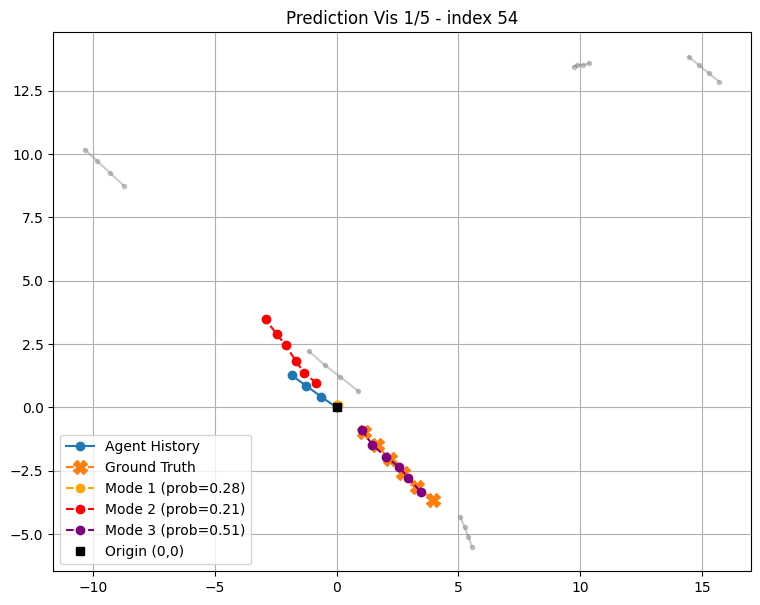

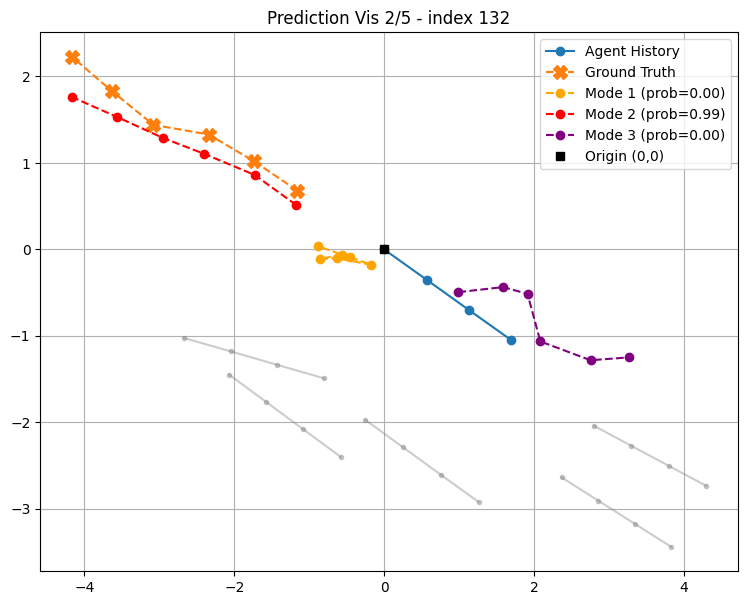

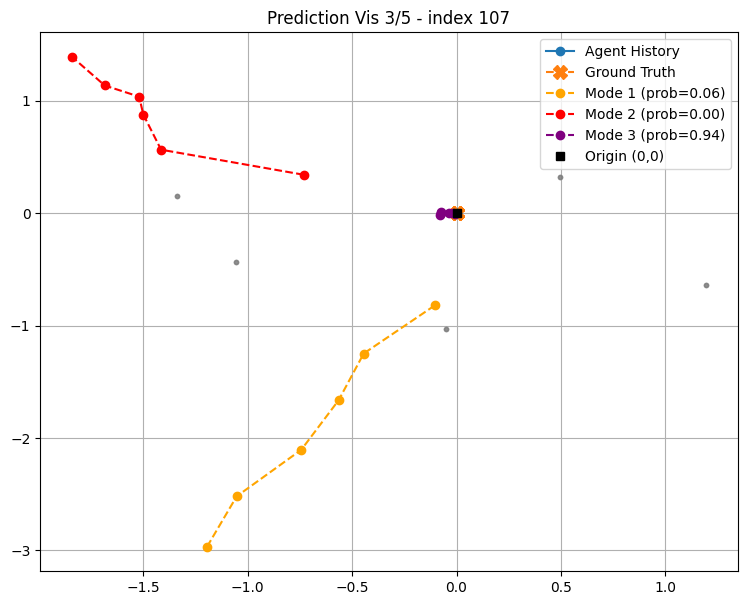

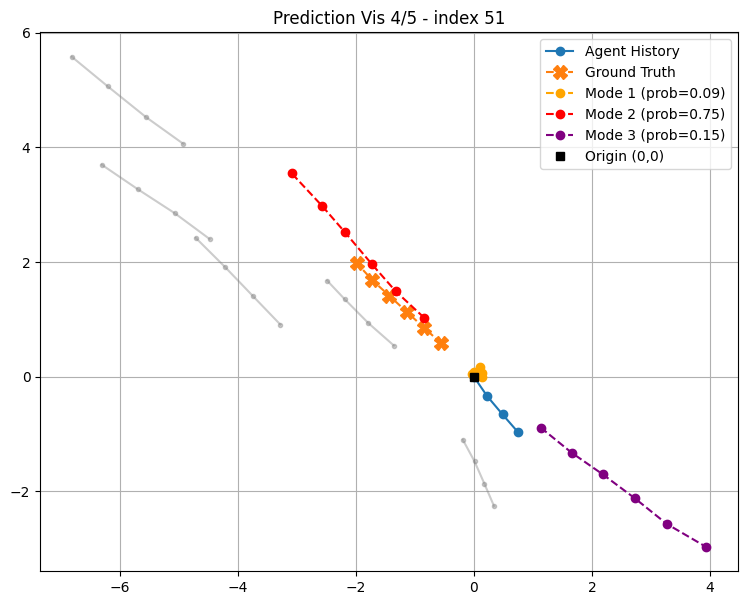

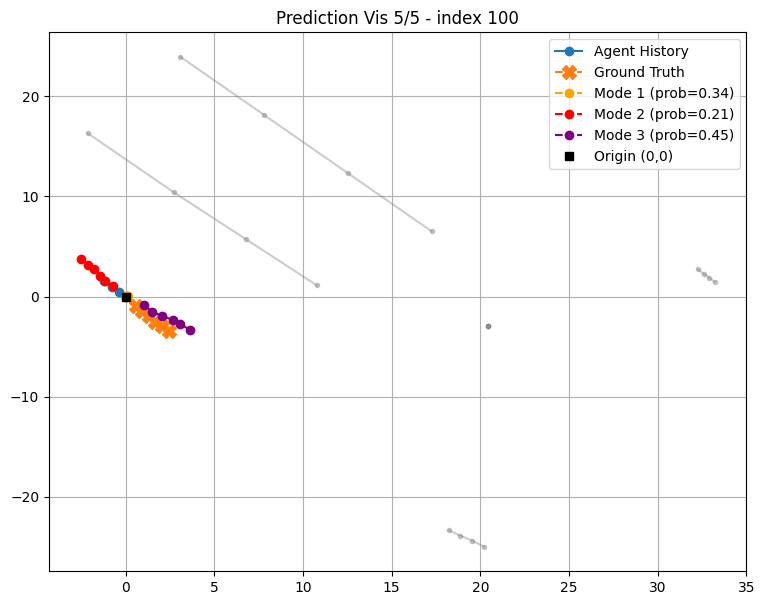

In [23]:
model.eval()

if len(X_target_off) > 0:
    import random # probably should be at the top of the file but whatever

    # grab 5 random examples to show the judges
    idx_list = random.sample(range(len(dataset)), min(5, len(dataset)))

    for plot_num, i in enumerate(idx_list):
        tgt_x, nbr_x, fut_y = dataset[i]

        with torch.no_grad():
            m_probs, m_preds = model(tgt_x.unsqueeze(0), nbr_x.unsqueeze(0))

        # rebuild actual global-ish coordinates from the offsets
        # print("offset shapes:", tgt_x.shape)

        t_past = np.cumsum(tgt_x.numpy(), axis=0)
        t_fut = np.cumsum(fut_y.numpy(), axis=0)

        m_probs = m_probs[0].numpy()
        pred_off = m_preds[0].numpy()
        pred_abs = np.cumsum(pred_off, axis=1) # (Modes, Steps, 2)

        plt.figure(figsize=(9, 7))
        plt.plot(t_past[:,0], t_past[:,1], 'o-', label='Agent History')
        plt.plot(t_fut[:,0], t_fut[:,1], 'X--', label='Ground Truth', markersize=10)

        # draw all the neighbors walking around
        for n_i in range(nbr_x.shape[0]):
            n_tr = nbr_x[n_i].numpy()
            if np.any(n_tr): # ignore the zero-padded empty neighbors
                plt.plot(n_tr[:,0], n_tr[:,1], '.-', color='gray', alpha=0.4)

        # draw the 3 mode predictions
        c_list = ['orange', 'red', 'purple']
        for m in range(model.modes):
            plt.plot(pred_abs[m, :, 0], pred_abs[m, :, 1], 'o--',
                     label=f'Mode {m+1} (prob={m_probs[m]:.2f})', color=c_list[m])

        plt.plot(0, 0, 'ks', label='Origin (0,0)')
        plt.title(f"Prediction Vis {plot_num+1}/5 - index {i}")
        plt.grid()
        plt.legend()
        plt.show()
